# Act 3-1 - Detección de Peatones con SVM

**Equipo 2**  

A01570123 - Carlos Enrique García Díaz  
A01796851 - Kenji Omar Ramírez Álvarez  
A01796858 - Luis Esteban Barranco Guida  
A01100001 - Alejandro Eli Acosta Flores

## Se cargan las bibliotecas necesarias

In [154]:
# Librerías comunes
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import cv2

# Librerías agregadas
from skimage.feature import hog
from pathlib import Path
import glob
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV
import joblib

%matplotlib inline

## Se importan los datasets

- **Dataset utilizado -** Imágenes positivas y negativas de peatones: https://github.com/cristianrohr/ECI-DATCOM-UGR_Deteccion_peatones.git

- *No se utulizó -* Imágenes positivas y negativas de peatones: https://www.kaggle.com/datasets/tejasvdante/pedestrian-no-pedestrian

- *No se utulizó -* Imágenes positivas de peatones: https://www.kaggle.com/datasets/jcoral02/inriaperson

In [155]:
# Rutas locales de los datasets
DATASETS_ROOT = Path("Pedestrain datasets")

# Rutas locales de los datasets descargados
ECI_DATCOM_UGR_ROOT = DATASETS_ROOT / "ECI_DATCOM_UGR"
PEDESTRIAN_NO_PEDESTRIAN_ROOT = DATASETS_ROOT / "pedestrian no pedestrian"
INRIA_ROOT = DATASETS_ROOT / "INRIAPerson"

print("Pedestrian / No Pedestrian root:", ECI_DATCOM_UGR_ROOT)
print("ECI-DATCOM-UGR root:", ECI_DATCOM_UGR_ROOT)

print("\nPedestrian / No Pedestrian root:", PEDESTRIAN_NO_PEDESTRIAN_ROOT)
print("INRIAPerson root:", INRIA_ROOT)

print("\nExiste Pedestrian / No Pedestrian:", PEDESTRIAN_NO_PEDESTRIAN_ROOT.exists())
print("Existe INRIAPerson:", INRIA_ROOT.exists())

Pedestrian / No Pedestrian root: Pedestrain datasets\ECI_DATCOM_UGR
ECI-DATCOM-UGR root: Pedestrain datasets\ECI_DATCOM_UGR

Pedestrian / No Pedestrian root: Pedestrain datasets\pedestrian no pedestrian
INRIAPerson root: Pedestrain datasets\INRIAPerson

Existe Pedestrian / No Pedestrian: True
Existe INRIAPerson: True


In [181]:
# Dataset Pedestrian / No Pedestrian
pedestrian = (
    glob.glob(str(ECI_DATCOM_UGR_ROOT / "train" / "pedestrians" / "*.jpg")) +
    glob.glob(str(ECI_DATCOM_UGR_ROOT / "validation" / "pedestrians" / "*.jpg")) +
    glob.glob(str(ECI_DATCOM_UGR_ROOT / "train" / "pedestrians" / "*.png")) +
    glob.glob(str(ECI_DATCOM_UGR_ROOT / "validation" / "pedestrians" / "*.png")) +
    glob.glob(str(ECI_DATCOM_UGR_ROOT / "train" / "pedestrians" / "*.jpeg")) +
    glob.glob(str(ECI_DATCOM_UGR_ROOT / "validation" / "pedestrians" / "*.jpeg"))
)

no_pedestrian = (
    glob.glob(str(ECI_DATCOM_UGR_ROOT / "train" / "background" / "*.jpg")) +
    glob.glob(str(ECI_DATCOM_UGR_ROOT / "validation" / "background" / "*.jpg")) +
    glob.glob(str(ECI_DATCOM_UGR_ROOT / "train" / "background" / "*.png")) +
    glob.glob(str(ECI_DATCOM_UGR_ROOT / "validation" / "background" / "*.png")) +
    glob.glob(str(ECI_DATCOM_UGR_ROOT / "train" / "background" / "*.jpeg")) +
    glob.glob(str(ECI_DATCOM_UGR_ROOT / "validation" / "background" / "*.jpeg"))
)

print(f"Imágenes de peatones ECI encontradas en primer dataset: {len(pedestrian)}")
print(f"Imágenes de no peatones ECI encontradas: {len(no_pedestrian)}")

Imágenes de peatones ECI encontradas en primer dataset: 1916
Imágenes de no peatones ECI encontradas: 2390


In [182]:
RUN_CELL = False

if RUN_CELL:
    # Dataset Pedestrian / No Pedestrian
    pedestrian = (
        glob.glob(str(PEDESTRIAN_NO_PEDESTRIAN_ROOT / "train" / "pedestrian" / "*.jpg")) +
        glob.glob(str(PEDESTRIAN_NO_PEDESTRIAN_ROOT / "validation" / "pedestrian" / "*.jpg")) +
        glob.glob(str(PEDESTRIAN_NO_PEDESTRIAN_ROOT / "train" / "pedestrian" / "*.png")) +
        glob.glob(str(PEDESTRIAN_NO_PEDESTRIAN_ROOT / "validation" / "pedestrian" / "*.png")) +
        glob.glob(str(PEDESTRIAN_NO_PEDESTRIAN_ROOT / "train" / "pedestrian" / "*.jpeg")) +
        glob.glob(str(PEDESTRIAN_NO_PEDESTRIAN_ROOT / "validation" / "pedestrian" / "*.jpeg"))
    )

    no_pedestrian = (
        glob.glob(str(PEDESTRIAN_NO_PEDESTRIAN_ROOT / "train" / "no pedestrian" / "*.jpg")) +
        glob.glob(str(PEDESTRIAN_NO_PEDESTRIAN_ROOT / "validation" / "no pedestrian" / "*.jpg")) +
        glob.glob(str(PEDESTRIAN_NO_PEDESTRIAN_ROOT / "train" / "no pedestrian" / "*.png")) +
        glob.glob(str(PEDESTRIAN_NO_PEDESTRIAN_ROOT / "validation" / "no pedestrian" / "*.png")) +
        glob.glob(str(PEDESTRIAN_NO_PEDESTRIAN_ROOT / "train" / "no pedestrian" / "*.jpeg")) +
        glob.glob(str(PEDESTRIAN_NO_PEDESTRIAN_ROOT / "validation" / "no pedestrian" / "*.jpeg"))
    )

    print(f"Imágenes de peatones encontradas en primer dataset: {len(pedestrian)}")
    print(f"Imágenes de no peatones encontradas: {len(no_pedestrian)}")

In [183]:
if RUN_CELL:
    # INRIAPerson: imágenes positivas adicionales de peatones
    inria_pedestrian = (
        glob.glob(str(INRIA_ROOT / "Train" / "**" / "*.jpg"), recursive=True) +
        glob.glob(str(INRIA_ROOT / "Train" / "**" / "*.png"), recursive=True) +
        glob.glob(str(INRIA_ROOT / "Train" / "**" / "*.jpeg"), recursive=True) +
        glob.glob(str(INRIA_ROOT / "Test" / "**" / "*.jpg"), recursive=True) +
        glob.glob(str(INRIA_ROOT / "Test" / "**" / "*.png"), recursive=True) +
        glob.glob(str(INRIA_ROOT / "Test" / "**" / "*.jpeg"), recursive=True)
    )

    print(f"Imágenes de peatones encontradas en INRIAPerson: {len(inria_pedestrian)}")

    # Se combinan las imágenes positivas
    pedestrian.extend(inria_pedestrian)

    print(f"\nTotal de imágenes positivas de peatones: {len(pedestrian)}")
    print(f"Total de imágenes negativas de no peatones: {len(no_pedestrian)}")

## Nota sobre balance de clases

Al agregar INRIAPerson se incrementa el número de ejemplos positivos.  
Conviene revisar que las clases no queden demasiado desbalanceadas.  
  
*Dados los objetivos de la actividad, no se balancearán las clases en esta entrega.*

In [157]:
print("Peatones:", len(pedestrian))
print("No peatones:", len(no_pedestrian))

if len(no_pedestrian) > 0:
    print("Relación peatones/no peatones:", len(pedestrian) / len(no_pedestrian))

Peatones: 1916
No peatones: 2390
Relación peatones/no peatones: 0.801673640167364


## Se muestra una imagen con pedestrian

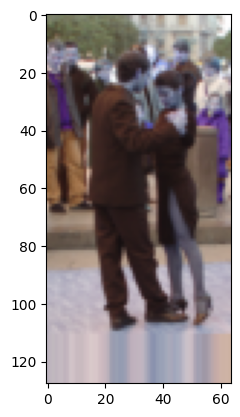

In [158]:
img_color = cv2.imread(pedestrian[10])
plt.imshow(img_color)

## Se calcula el HOG de la imagen

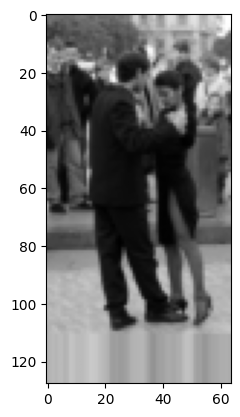

In [159]:
# Normalizamos las imágenes a un tamaño para el entrenamiento del detector SVM
# Nota: ara detección de peatones porque una persona normalmente ocupa una región más alta que ancha
TARGET_IMG_SIZE = (64, 128)  # (width, height)

img_resized = cv2.resize(img_color, TARGET_IMG_SIZE)
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap='gray')

In [160]:
features, hog_img = hog(img_gray,
                        orientations=11,
                        pixels_per_cell=(16,16),
                        cells_per_block=(2,2),
                        transform_sqrt=True,
                        visualize=True,
                        feature_vector=True)

In [161]:
print("Features shape:", features.shape)
print("HOG image shape:", hog_img.shape)

Features shape: (924,)
HOG image shape: (128, 64)


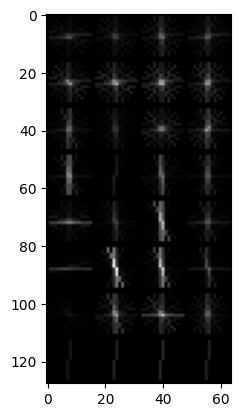

In [162]:
plt.imshow(hog_img, cmap='gray')

## Se extraen las features del HOG para ambos tipos de datos

In [163]:
def get_HOGFeatures(img_path, target_size=(64, 128)):

    # Leer imagen
    img_color = cv2.imread(img_path)

    # Ignorar si no se detecta una imagen
    if img_color is None:
        return None

    # Redimensionar para mantener una longitud fija del vector HOG
    img_resized = cv2.resize(img_color, target_size)

    # Convertir a escala de grises
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # Extraer características HOG
    features, _ = hog(img_gray,
                   orientations=11,
                   pixels_per_cell=(16, 16),
                   cells_per_block=(2, 2),
                   transform_sqrt=True,
                   visualize=True,
                   feature_vector=True)

    return features

In [164]:
# Inicializamos nuestro acumulador de imágenes positivas
pedestrian_hog_accum = []

# Extraermos las impágenes
for img_path in pedestrian:
    features = get_HOGFeatures(img_path, target_size=TARGET_IMG_SIZE)

    if features is not None:
        pedestrian_hog_accum.append(features)

# Etiquetamos las imágenes
X_pedestrian = np.vstack(pedestrian_hog_accum).astype(np.float64)
y_pedestrian = np.ones(len(X_pedestrian))

print(f"Vectores HOG de peatones extraídos: {len(pedestrian_hog_accum)}")
print(f"\nDimensiones de X_pedestrian: {X_pedestrian.shape}")
print(f"Dimensiones de y_pedestrian: {y_pedestrian.shape}")

Vectores HOG de peatones extraídos: 1916

Dimensiones de X_pedestrian: (1916, 924)
Dimensiones de y_pedestrian: (1916,)


In [165]:
# Inicializamos nuestro acumulador de imágenes negativas
nopedestrian_hog_accum = []

# Extraermos las impágenes
for img_path in no_pedestrian:
    features = get_HOGFeatures(img_path, target_size=TARGET_IMG_SIZE)

    if features is not None:
        nopedestrian_hog_accum.append(features)

# Etiquetamos las imágenes
X_nopedestrian = np.vstack(nopedestrian_hog_accum).astype(np.float64)
y_nopedestrian = np.zeros(len(X_nopedestrian))

print(f"Vectores HOG de no peatones extraídos: {len(nopedestrian_hog_accum)}")
print(f"\nDimensiones de X_nopedestrian: {X_nopedestrian.shape}")
print(f"Dimensiones de y_nopedestrian: {y_nopedestrian.shape}")

Vectores HOG de no peatones extraídos: 2390

Dimensiones de X_nopedestrian: (2390, 924)
Dimensiones de y_nopedestrian: (2390,)


## Se combinan ambos tipos de datos para alimentar el SVM

In [166]:
X = np.vstack((X_pedestrian, X_nopedestrian))
print(f"Dimensiones de X: {X.shape}")

y = np.hstack((y_pedestrian, y_nopedestrian))
print(f"Dimensiones de y: {y.shape}")

Dimensiones de X: (4306, 924)
Dimensiones de y: (4306,)


## Se generan los datos de entrenamiento y de prueba

In [167]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

Dimensiones de X_train: (3444, 924)
Dimensiones de X_test: (862, 924)


## Se importa el Clasificador y se entrena

In [168]:
# from sklearn.svm import LinearSVC
# svc_model = LinearSVC()
# svc_model.fit(X_train, y_train)

from sklearn.svm import SVC

svc_model = SVC()
svc_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


<Axes: >

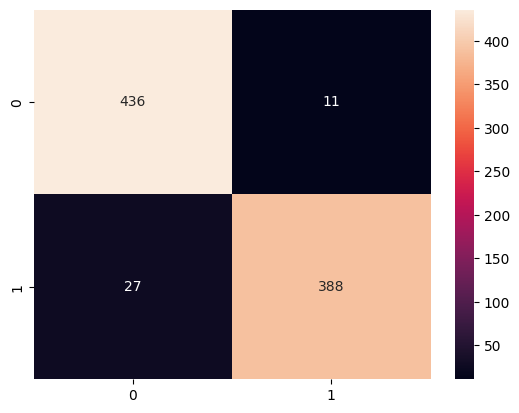

In [169]:
# Ejecutamos nuestro modelo con nuestro set de prueba
y_predict = svc_model.predict(X_test)

# Evaluamos el modelo
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot=True, fmt='d')

In [170]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96       447
         1.0       0.97      0.93      0.95       415

    accuracy                           0.96       862
   macro avg       0.96      0.96      0.96       862
weighted avg       0.96      0.96      0.96       862



## GridSearchCV

In [171]:
# Realizamos validción cruzada para mejorar nuestra selección de parámetros
param_grid = {'C': [0.1, 1, 10, 100, 1000], 'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 'kernel': ['rbf']}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=4)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.563 total time=   6.7s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.565 total time=   4.9s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.565 total time=   4.4s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.565 total time=   3.9s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.564 total time=   3.9s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.951 total time=   1.9s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.967 total time=   1.5s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.968 total time=   1.7s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.946 total time=   1.7s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.935 total time=   1.6s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.914 total time=   2.6s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and c

In [172]:
# Vemos los mejores parámetros obtenidos
grid.best_params_

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

In [173]:
grid.best_estimator_

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


<Axes: >

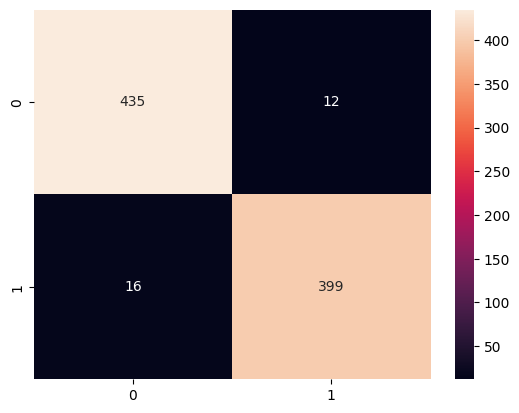

In [174]:
# Ejecutamos nuestro modelo "grid" con nuestro set de prueba
grid_predictions = grid.predict(X_test)

# Evaluamos el modelo
cm = confusion_matrix(y_test, grid_predictions)
sns.heatmap(cm, annot=True, fmt='d')

In [175]:
print(classification_report(y_test, grid_predictions))

              precision    recall  f1-score   support

         0.0       0.96      0.97      0.97       447
         1.0       0.97      0.96      0.97       415

    accuracy                           0.97       862
   macro avg       0.97      0.97      0.97       862
weighted avg       0.97      0.97      0.97       862



In [176]:
# Métricas del modelo SVC base
svc_accuracy = accuracy_score(y_test, y_predict)
svc_f1 = f1_score(y_test, y_predict, average='weighted')

# Métricas del modelo optimizado con GridSearchCV
grid_accuracy = accuracy_score(y_test, grid_predictions)
grid_f1 = f1_score(y_test, grid_predictions, average='weighted')

print("===== Modelo SVC base =====")
print(f"Accuracy: {svc_accuracy:.4f}")
print(f"F1-score: {svc_f1:.4f}")

print("\n===== Modelo GridSearchCV =====")
print(f"Accuracy: {grid_accuracy:.4f}")
print(f"F1-score: {grid_f1:.4f}")

# Selección del mejor modelo con base en F1-score
if grid_f1 > svc_f1:
    best_model = grid
    best_model_name = "GridSearchCV"
    best_accuracy = grid_accuracy
    best_f1 = grid_f1
    model = grid
else:
    best_model = svc_model
    best_model_name = "SVC base"
    best_accuracy = svc_accuracy
    best_f1 = svc_f1
    model= svc_model

print("\n===== Mejor modelo seleccionado =====")
print(f"Modelo: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"F1-score: {best_f1:.4f}")

===== Modelo SVC base =====
Accuracy: 0.9559
F1-score: 0.9559

===== Modelo GridSearchCV =====
Accuracy: 0.9675
F1-score: 0.9675

===== Mejor modelo seleccionado =====
Modelo: GridSearchCV
Accuracy: 0.9675
F1-score: 0.9675


In [177]:
# Se usa joblib para guardar el modelo
filename = "svm_pedestrian_detector_ECI_sqrt.pkl"
joblib.dump(best_model, filename)

['svm_pedestrian_detector_ECI_sqrt.pkl']